Chapter 29
# 处理离群值
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

离群值 (outlier)，又称逸出值、离群值，是指数据集中与其他数据点有显著差异的数据点，也
就是说明显地偏大或偏小。

离群值可能是由于异常情况、错误测量、数据录入错误或意外事件等原因而产生。离群值可能会对
数据分析和建模造成问题，因为它们可能导致误差或偏差，并降低模型的准确性。因此，数据分析师通
常会对数据集中的离群值进行检测和处理。

常见的离群值检测方法包括基于统计学的方法、基于距离的方法、基于密度的方法和基于模型的方
法。处理离群值的方法包括删除、替换、调整或利用异常值建立新的模型等。


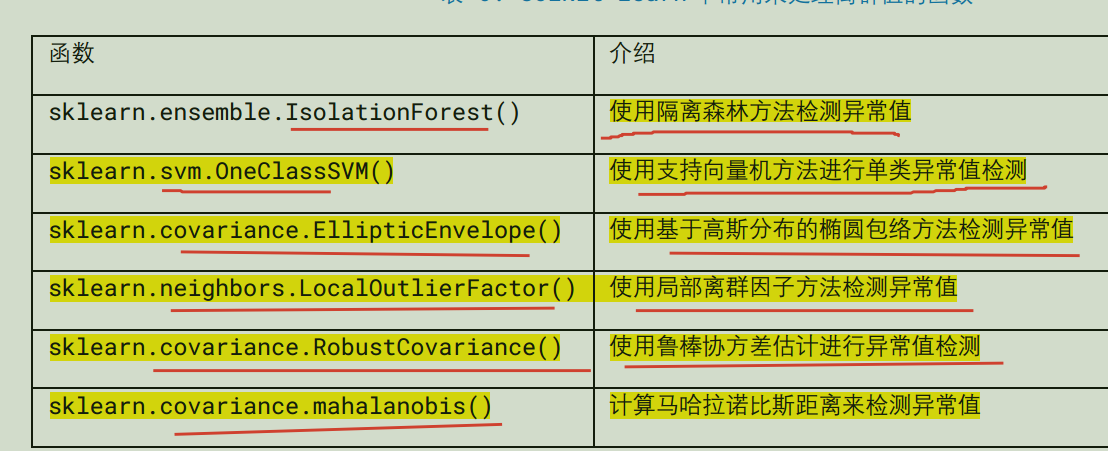

moons：半月形分布（非线性可分）
blobs：高斯簇（线性可分）

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs, make_moons
from sklearn.svm import OneClassSVM # 支持向量机
from sklearn.covariance import EllipticEnvelope # 基于高斯分布的椭圆包络
from sklearn.ensemble import IsolationForest # 隔离森林

## 生成数据

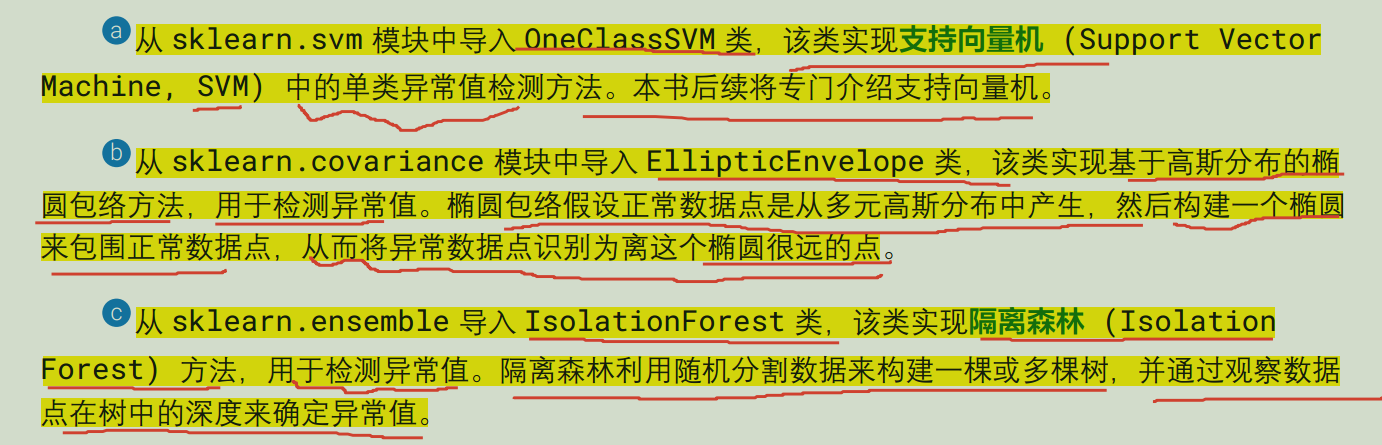

In [4]:
# 生成数据
n_samples = 500 # 样本数量
outliers_fraction = 0.10 # 离群值比例因子
n_outliers = int(outliers_fraction * n_samples) # 离群样本数
n_inliers  = n_samples - n_outliers # 正常值

# 生成异常值；每一行就是一个点（x，y）
X_outliers = np.random.uniform(low=-6,high=6,
                               size=(n_outliers,2))

In [5]:
X_outliers

array([[-1.78745102,  1.28168668],
       [-2.58802266,  5.26547275],
       [ 0.2185375 , -0.69785396],
       [-4.89313023,  4.17501972],
       [ 4.98560119, -5.40475259],
       [ 0.698865  , -1.71379203],
       [-0.86159019,  2.61187451],
       [ 5.49115691,  3.09840134],
       [ 1.44621616,  3.1106381 ],
       [ 2.35490855,  2.60606024],
       [ 5.46095569, -5.13379416],
       [ 1.71742775, -3.44893473],
       [ 4.92268724,  3.28121259],
       [ 1.92221527,  5.14499008],
       [ 4.51976315, -2.06127152],
       [-5.17631536, -4.77298536],
       [-3.8103104 , -0.45468011],
       [-4.71201072,  3.82672554],
       [ 3.91068858,  3.93611374],
       [-0.80046555,  0.98339637],
       [ 2.71042541,  0.65458439],
       [ 2.76478646,  0.11160906],
       [ 0.90933613, -3.47965532],
       [-5.66423961,  2.0906104 ],
       [ 1.04746397, -2.61013259],
       [-5.85705086, -5.27341648],
       [ 0.69658851,  4.99455131],
       [-4.96127724,  3.07612579],
       [-0.35117914,

定义了一个名为 blobs_params 的字典，其中包含了一些参数设置。
random_state=0 用
于控制随机数生成的种子值。

n_samples=n_inliers 控制生成的总样本数。

n_features=2 设定每
个数据点的特征数量为 2，即两个特征。


In [7]:
np.random.RandomState(0) # 随机数种子
blobs_params = dict(random_state=0,
                    n_samples=n_inliers, n_features=2)

##构建数据集

In [8]:
datasets = [
    make_blobs(centers=[[0, 0], [0, 0]],  # 质心位置
               cluster_std=0.5, **blobs_params)[0], #每个聚类的标准差
    #**blobs_params：解包字典；作为参数
    # make_blobs()返回一个元组（data, labels）【0】取数据
    make_blobs(centers=[[2, 2], [-2, -2]],
               cluster_std=[0.5, 0.5], **blobs_params)[0],
    make_blobs(centers=[[2, 2], [-2, -2]],
               cluster_std=[1.5, 0.3], **blobs_params)[0],

    # 每个数据减去[0.5, 0.25]
    4.0 * (make_moons(n_samples=n_samples, noise=0.05,
           random_state=0)[0]- np.array([0.5, 0.25]))]

### 展示部分数据结构

In [15]:
test=make_blobs(centers=[[0, 0], [0, 0]],
               cluster_std=0.5, **blobs_params)
print(type(test))
test[1]

<class 'tuple'>


array([0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,

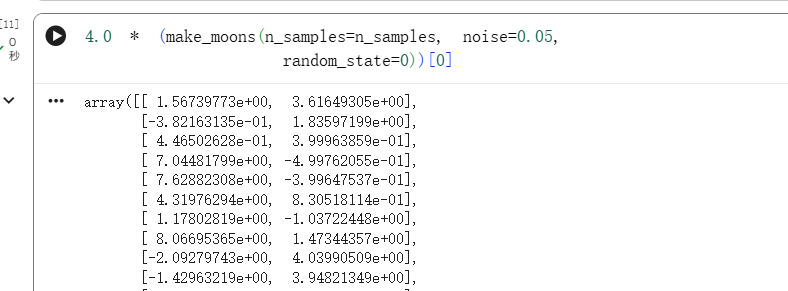

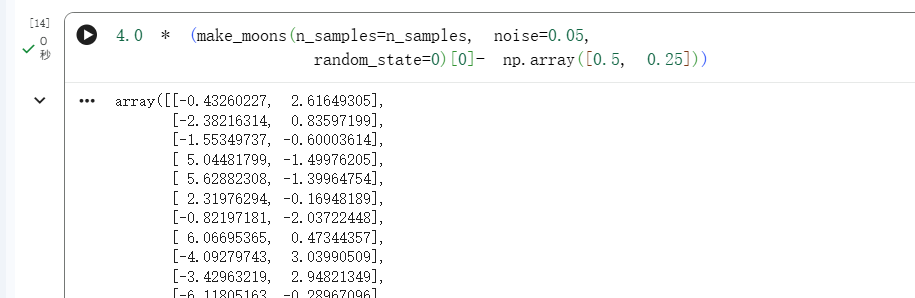

In [ ]:
4.0 * (make_moons(n_samples=n_samples, noise=0.05,
           random_state=0)[0]- np.array([0.5, 0.25]))

# 处理离群值

用 EllipticEnvelope() 创建椭圆包络的异常值检测模型。

参数 contamination 用于指定
异常值的比例。具体来说，它表示数据中异常值的比例。这个参数是一个介于 0 和 0.5 之间的值，

通常需要根据具体问题进行调整。参数 random_state 用于控制随机数生成的种子值，以确保每次运
行得到相同的结果

使用 OneClassSVM() 创建一个基于支持向量机的异常值检测模型。参数 nu 用于指定异常值
的比例，

通常在 0 和 1 之间。kernel="rbf" 指定支持向量机所使用的核函数的类型。

"rbf" 表
示径向基函数 (Radial Basis Function, RBF)，也称为高斯核。


这个核函数在支持向量机中常用于处理非线性问题。gamma=0.1 是支持向量机模型的核函数参
数。较小的 gamma 值会使得支持向量具有更远的影响范围，可能会导致决策边界更平滑；较大的
gamma 值则会使支持向量的影响范围更小，可能会导致决策边界更复杂。


使用 IsolationForest() 创建一个基于隔离森林的异常值检测模型。

 i
使用 fit() 方法
对样本数据进行拟合，然后使用 predict() 方法来预测数据点是否为异常值。


In [17]:
# 处理离群值
# 使用三种方法
anomaly_algorithms = [
     EllipticEnvelope(contamination=outliers_fraction,
                      random_state=42),
     OneClassSVM(nu=outliers_fraction, kernel="rbf",
                 gamma=0.1),
     IsolationForest(contamination=outliers_fraction,
                     random_state=42)]



```
xx_flat = xx.ravel()
yy_flat = yy.ravel()

print("xx.ravel():", xx_flat)
# [-2. -1.  0.  1.  2. -2. -1.  0.  1.  2. -2. -1.  0.  1.  2. -2. -1.  0.  1.  2. -2. -1.  0.  1.  2.]

print("yy.ravel():", yy_flat)
# [-2. -2. -2. -2. -2. -1. -1. -1. -1. -1.  0.  0.  0.  0.  0.  1.  1.  1.  1.  1.  2.  2.  2.  2.  2.]
```





```
result = np.c_[xx.ravel(), yy.ravel()]
print(result)
# [[-2. -2.]
#  [-1. -2.]
#  [ 0. -2.]
#  [ 1. -2.]
#  [ 2. -2.]
#  [-2. -1.]
#  [-1. -1.]
#  [ 0. -1.]
#  [ 1. -1.]
#  [ 2. -1.]
#  [-2.  0.]
#  [-1.  0.]
#  [ 0.  0.]
#  [ 1.  0.]
#  [ 2.  0.]
#  [-2.  1.]
#  [-1.  1.]
#  [ 0.  1.]
#  [ 1.  1.]
#  [ 2.  1.]
#  [-2.  2.]
#  [-1.  2.]
#  [ 0.  2.]
#  [ 1.  2.]
#  [ 2.  2.]]
```



In [18]:
# 网格化数据，用来绘制等高线
xx, yy = np.meshgrid(np.linspace(-7, 7, 150),
                     np.linspace(-7, 7, 150))
# xx,yy: 150*150
# 展为一维数组；每一行就是一个点 np.c_ 是 按列（column）拼接 的快捷方式：
# 注意行列拼接
xy = np.c_[xx.ravel(), yy.ravel()] # (150*150) * 2

# 颜色；区分正常值与异常值
colors = np.array(["#377eb8", "#ff7f00"])

# 可视化

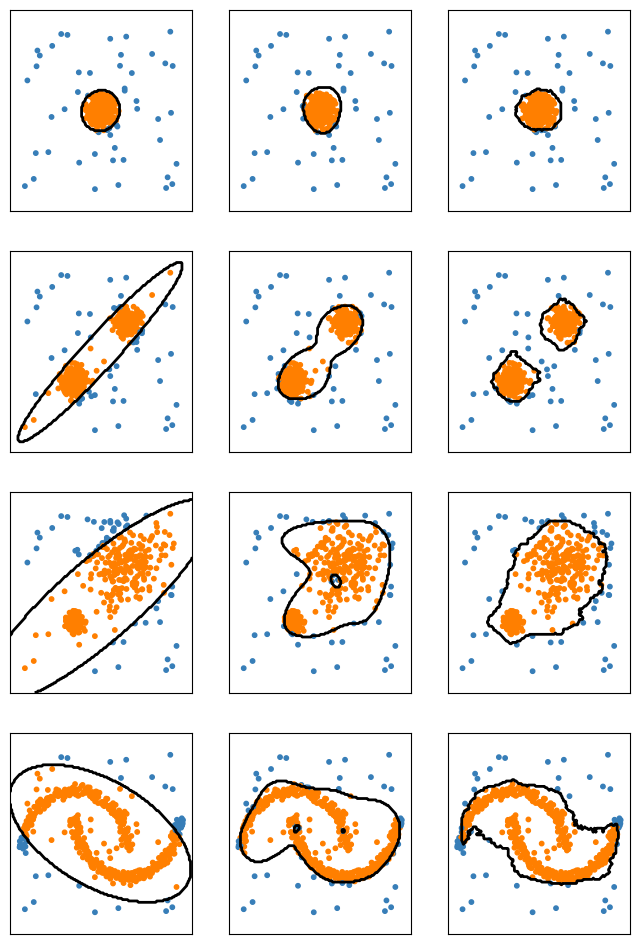

In [19]:
# 可视化
fig = plt.figure(figsize=(8,12))
plot_idx = 1
# enumerate(datasets)： 索引：数据
for idx, X in enumerate(datasets):
  # 正常数据(data数据集生成的)与异常数据（X_outliers = np.random.uniform(low=-6,high=6,size=(n_outliers,2))）
  # 按照 axis行拼接  450*2 与 50*2 ==> 500*2
  # 将全局异常点 X_outliers 拼接到每个数据集末尾。
    X = np.concatenate([X, X_outliers], axis=0)
    # 对每个数据分别执行不同的离群值的处理算法
    for algorithm in anomaly_algorithms:
        algorithm.fit(X)
        # 对样本进行拟合；在预测数据点是否为异常值
        y_pred = algorithm.fit(X).predict(X)
        # plot_idx：子图的序号（12）
        ax = fig.add_subplot(4,3,plot_idx); plot_idx += 1

        # 对每个坐标点进行预测
        Z = algorithm.predict(xy)
        # 转为 150 * 150
        Z = Z.reshape(xx.shape)
        # 绘制边界
        # predict 返回：1（正常）或 -1（异常）levels=[0]：绘制决策边界（分数为0的等高线）。
        ax.contour(xx, yy, Z, levels=[0],
                    linewidths=2, colors="black")
        # 绘制散点数据集

        '''
        y_pred 是 -1 或 1
        (y_pred + 1) // 2 映射为 0 或 1
        colors[0] = 蓝色（正常），colors[1] = 橙色（异常）
        第 一二列数据； s; 点的大小
        '''
        ax.scatter(X[:, 0], X[:, 1], s=10,
                   color=colors[(y_pred + 1) // 2])


        ax.set_xlim(-7, 7); ax.set_ylim(-7, 7) # 范围
        ax.set_xticks(()); ax.set_yticks(()) # 不显示刻度

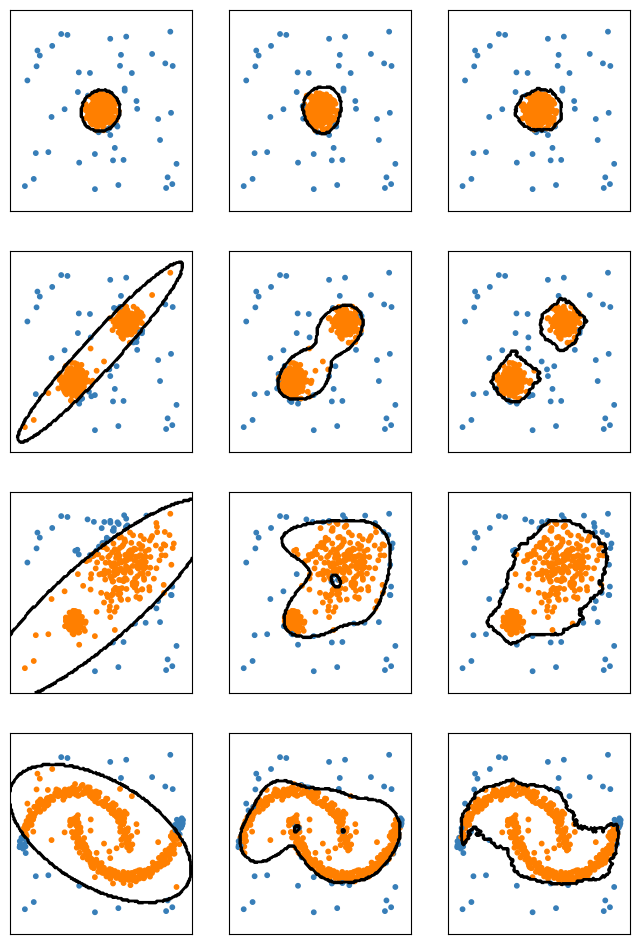

In [20]:
# 可视化
fig = plt.figure(figsize=(8,12))
plot_idx = 1
# enumerate(datasets)： 索引：数据
for idx, X in enumerate(datasets):
  # 正常数据(data数据集生成的)与异常数据（X_outliers = np.random.uniform(low=-6,high=6,size=(n_outliers,2))）
  # 按照 axis行拼接  450*2 与 50*2 ==> 500*2
  # 将全局异常点 X_outliers 拼接到每个数据集末尾。
    X = np.concatenate([X, X_outliers], axis=0)
    # 对每个数据分别执行不同的离群值的处理算法
    for algorithm in anomaly_algorithms:
        algorithm.fit(X)
        # 对样本进行拟合；在预测数据点是否为异常值
        y_pred = algorithm.fit(X).predict(X)
        # plot_idx：子图的序号（12）
        ax = fig.add_subplot(4,3,plot_idx); plot_idx += 1

        # 对每个坐标点进行预测
        Z = algorithm.predict(xy)
        # 转为 150 * 150
        Z = Z.reshape(xx.shape)
        # 绘制边界
        # predict 返回：1（正常）或 -1（异常）levels=[0]：绘制决策边界（分数为0的等高线）。
        ax.contour(xx, yy, Z, levels=[-1,0,1],
                    linewidths=2, colors="black")
        # 绘制散点数据集

        '''
        y_pred 是 -1 或 1
        (y_pred + 1) // 2 映射为 0 或 1
        colors[0] = 蓝色（正常），colors[1] = 橙色（异常）
        第 一二列数据； s; 点的大小
        '''
        ax.scatter(X[:, 0], X[:, 1], s=10,
                   color=colors[(y_pred + 1) // 2])


        ax.set_xlim(-7, 7); ax.set_ylim(-7, 7) # 范围
        ax.set_xticks(()); ax.set_yticks(()) # 不显示刻度